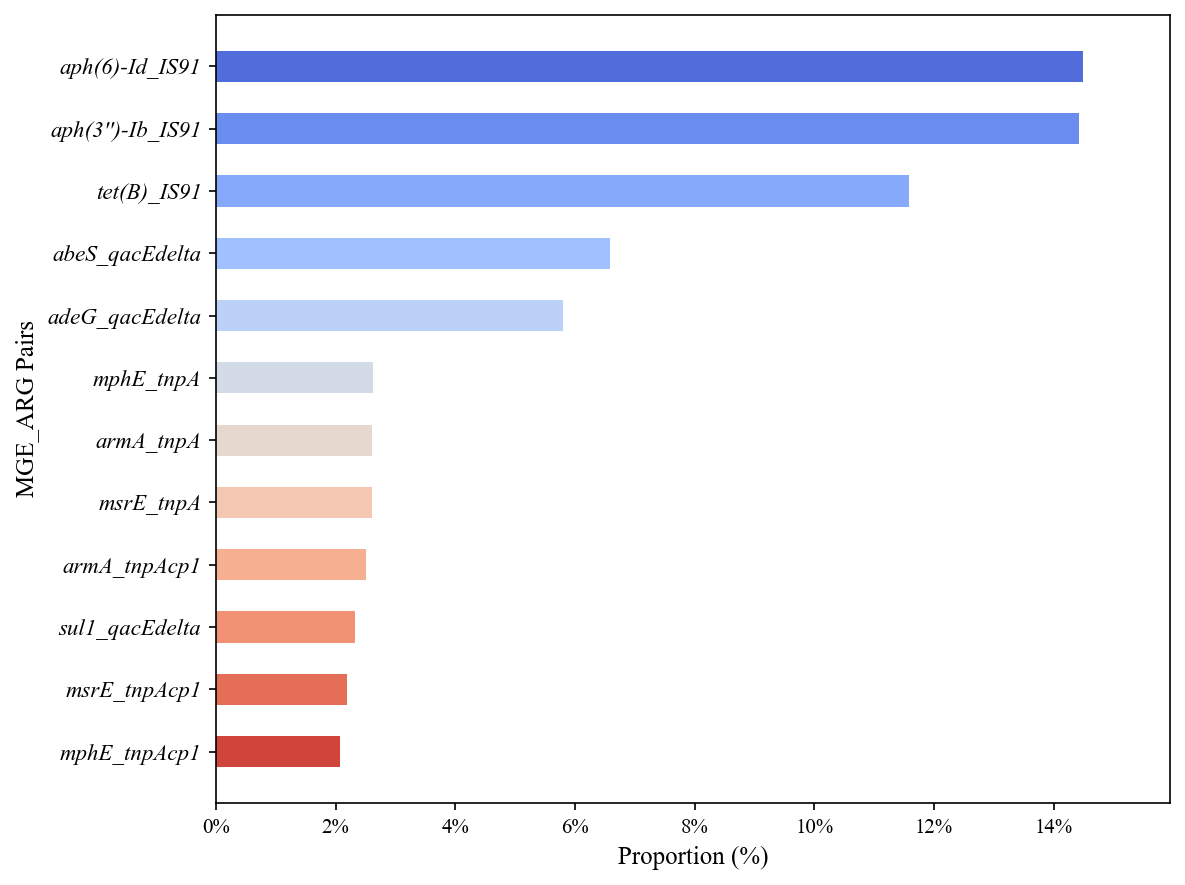

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
from matplotlib.ticker import PercentFormatter

# ==========================================
# 1. 全局字体与公式字体设置
# ==========================================
plt.rcParams['font.family'] = 'Times New Roman'
# 保证数学公式内部的 \mathrm{} 依然使用 Times New Roman 的正体
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
# （建议加上这行）保证如果触发了数学斜体，也使用不加粗的新罗马
plt.rcParams['mathtext.it'] = 'Times New Roman:italic' 

# ==========================================
# 2. 数据读取与预处理
# ==========================================
# 读取当前目录下所有 ARG_MGE*_clean.csv 文件并合并
file_paths = glob.glob(r'D:\A.baumannii\data\ARG_MGE_*_filtered.csv')

if len(file_paths) == 0:
    print("未找到文件，请检查文件路径！")
    
df_list = [pd.read_csv(file) for file in file_paths]
df = pd.concat(df_list, ignore_index=True)

# 拼接 ARG_Gene 和 mge_id 列
df['MGE_ARG_Pair'] = df['ARG_Gene'] + '_' + df['mge_id']

# 计算每种 Pair 的数量并转换为百分比比例
pair_counts = df['MGE_ARG_Pair'].value_counts()
pair_props = (pair_counts / pair_counts.sum()) * 100

# 取占比最高的前 12 个，并进行升序排序
top_10_pairs = pair_props.head(12).sort_values(ascending=True)

# ==========================================
# 3. 核心修改：文本+公式混合排版
# ==========================================
def format_pair_label(pair_name):
    if '_' in pair_name:
        arg_part, mge_part = pair_name.split('_', 1)
    else:
        arg_part, mge_part = pair_name, ""

    # 1. APH, AAC, ANT 替换小写
    if arg_part.startswith(("APH", "AAC", "ANT")):
        arg_part = arg_part[:3].lower() + arg_part[3:]
        
    # 2. 格式化逻辑
    if arg_part.startswith("bla"):
        # bla保留为普通文本，下标进入数学模式并用 \mathrm 强制正体
        suffix = arg_part[3:]
        suffix_math = suffix.replace('-', r'}\text{-}\mathrm{')
        arg_formatted = rf"bla$_{{\mathrm{{{suffix_math}}}}}$"
    else:
        # 普通基因(如 aph(3'')-Ib) 完全保留为普通文本，不进入公式！
        arg_formatted = arg_part
        
    # 3. 拼接 MGE 部分
    if mge_part:
        # 【核心修改】：去掉了 $\mathrm{...}$ 的正体锁定。
        # 把它当作纯文本拼在后面。配合最下方的 set_fontstyle('italic')，它自然就会变成斜体了！
        return f"{arg_formatted}_{mge_part}"
    
    return arg_formatted

top_10_pairs.index = top_10_pairs.index.map(format_pair_label)

# ==========================================
# 4. 绘制图一：MGE_ARG Pairs 的水平条形图
# ==========================================
fig1, ax1 = plt.subplots(figsize=(8, 6), dpi=150)

# 设置渐变颜色
colors = sns.color_palette("coolwarm_r", len(top_10_pairs))

bars = ax1.barh(top_10_pairs.index, top_10_pairs.values, color=colors, height=0.5)

# 设置轴标签和格式
ax1.set_xlabel('Proportion (%)', fontsize=12)
ax1.set_ylabel('MGE_ARG Pairs', fontsize=12)
ax1.set_xlim(0, top_10_pairs.max() * 1.1) 

ax1.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# ==========================================
# 5. 强制 Y 轴整体斜体
# ==========================================
# 将 Y 轴标签整体设为斜体。
# MGE 和 前面的 ARG 会变成斜体，而 bla 的后缀因为在 \mathrm{} 保护下，依然保持正体下标。
for label in ax1.get_yticklabels():
    label.set_fontstyle('italic')
    label.set_fontsize(11)

plt.tight_layout()
plt.savefig('MGE_ARG_Pairs.png', dpi=600, bbox_inches='tight')
plt.show()


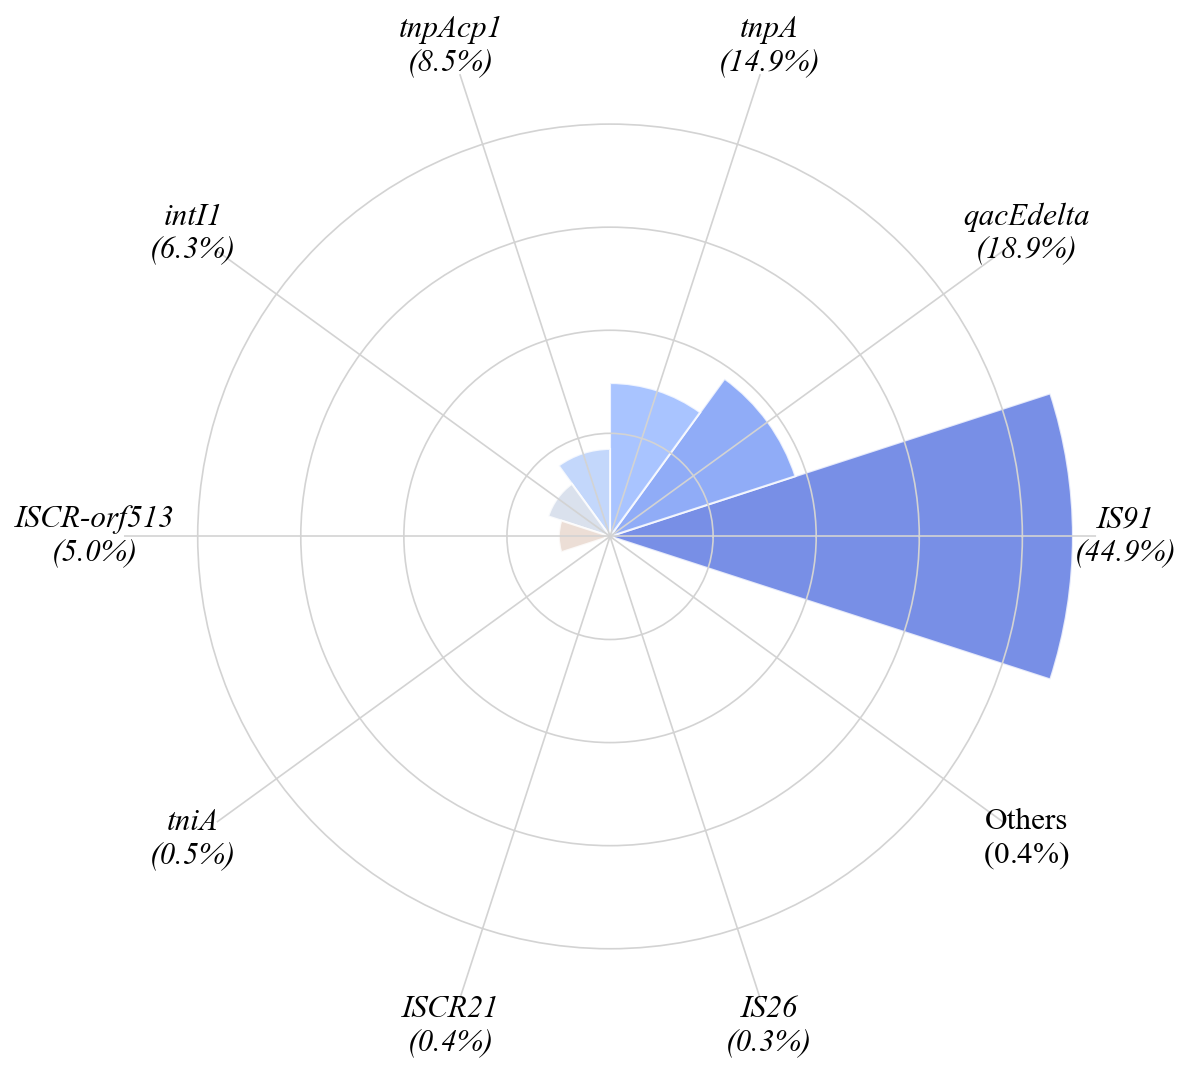

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob

# ==========================================
# 0. 全局字体与图形设置
# ==========================================
# 设置全局字体为 Times New Roman
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False 

# ================= 核心字体配置 =================
# 保证 Others 下方的公式语法渲染时，依然调用 Times New Roman
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Times New Roman'
plt.rcParams['mathtext.it'] = 'Times New Roman:italic'
# ================================================

# ==========================================
# 1. 数据读取与预处理
# ==========================================
# 读取当前目录下所有 ARG_MGE*_clean.csv 文件并合并
file_paths = glob.glob(r'D:\A.baumannii\data\ARG_MGE_*_filtered.csv')

if len(file_paths) == 0:
    print("未找到文件，请检查文件路径！")

df_list = [pd.read_csv(file) for file in file_paths]
df = pd.concat(df_list, ignore_index=True)

# ==========================================
# 2. 数据计算 (mge_id 占比)
# ==========================================
# 计算 mge_id 的频率并转换为百分比
mge_counts = df['mge_id'].value_counts()
mge_props = (mge_counts / mge_counts.sum()) * 100

# 提取前 9 个最常见的 MGE，将剩余的合并为 'Others'
top_n = 9
if len(mge_props) > top_n:
    top_mge = mge_props.head(top_n)
    others_prop = pd.Series({'Others': mge_props.iloc[top_n:].sum()})
    top_mge = pd.concat([top_mge, others_prop])
else:
    top_mge = mge_props

# ==========================================
# 3. 格式化标签文本
# ==========================================
labels = []
for idx, val in top_mge.items():
    if idx == 'Others':
        # Others 单词保持正体，下方的数字和百分号用 \mathit{} 变为斜体
        labels.append(f"Others\n" + rf"$\mathit{{({val:.1f}\%)}}$")
    else:
        # 【核心修改】普通 MGE 采用纯文本，不用 $ $ 包裹，避免数字不斜体或下划线被当成下标
        labels.append(f"{idx}\n({val:.1f}%)")

# ==========================================
# 4. 绘制南丁格尔玫瑰图
# ==========================================
values = top_mge.values
N = len(values)

# 计算每个扇形的角度位置
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()

fig2, ax2 = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True), dpi=150)

# 设置宽度使得各个扇形紧密相连
width = 2 * np.pi / N

# 设置颜色，突出占比最大的区域
rose_colors = sns.color_palette("coolwarm", N)

# 绘制柱状图（在极坐标下即为玫瑰图）
bars2 = ax2.bar(angles, values, width=width, bottom=0.0, 
                color=rose_colors, alpha=0.8, edgecolor='white')

# 设置刻度
ax2.set_xticks(angles)

# 【核心修改】绘制标签，并捕获标签对象集合
tick_labels = ax2.set_xticklabels(labels, fontsize=15)

# 遍历所有渲染好的标签，将非 Others 的标签强制设置纯斜体
# 这会保证 MGE 名称内部的数字（如 IS26 里的 26）和括号里的百分比100%斜体
for label in tick_labels:
    if 'Others' not in label.get_text():
        label.set_fontstyle('italic')

# 隐藏最外层的圆圈边框和 Y 轴（半径轴）的数字刻度
ax2.spines['polar'].set_visible(False)
ax2.set_yticklabels([])

# 设置网格线样式
ax2.grid(color='lightgray', linestyle='-', linewidth=0.8)

plt.tight_layout()
plt.savefig('mge_id_RoseChart.png', bbox_inches='tight', dpi=600)
plt.show()
